# Task 2

### **Configurations**
The complexity of the problem can be adjusted based on how events are structured and how much information the robot must process. Below are the **four defined environments** with increasing levels of difficulty.

#### **1. Easy: 3 Chests, 1 Event Per Chest** (`OpenTheChests-v0`)
- Each **chest is associated with a single event**.
- The robot **only needs to react to a single event** to identify the correct chest.
- **No historical context or sequence tracking** is required.
- **Challenge Level: Minimal** – A simple one-to-one mapping between an event and an action.
- Example:
  - **Event A** → Open **Chest 1**  
  - **Event B** → Open **Chest 2**  
  - **Event C** → Open **Chest 3**  

#### **2. Medium: 3 Chests, 4 Events Per Chest** (`OpenTheChests-v1`)
- Each chest is associated with **a sequence of 4 events**.
- The robot **must recognize short event sequences** to determine the correct chest.
- **Some memory and sequence tracking** are required.
- **Challenge Level: Moderate** – The robot must understand simple temporal dependencies.
- Example:
  - **Event A → Event B → Event C → Event D** → Open **Chest 1**  
  - **Event X → Event Y → Event Z → Event W** → Open **Chest 2**  
  - **Event M → Event N → Event O → Event P** → Open **Chest 3**  

#### **3. Hard: 3 Chests, 16 Events Per Chest** (`OpenTheChests-v2`)
- Each chest is associated with a **complex sequence of 16 events**.
- The robot **must track long-term dependencies** between events.
- **Deep memory and advanced pattern recognition** are necessary.
- **Challenge Level: High** – The robot must handle **complex sequential dependencies** and **avoid distractions**.
- Example:
  - **Event red A → after blue B → during C → after D → ... → Event P** → Open **Chest 1**  
  - **Event X → during red Y → after pink Z → during W → ... → Event O** → Open **Chest 2**  
  - **Event M → met_by N → during O → after P → ... → Event R** → Open **Chest 3**  

### **Testing Different Complexity Levels**
These three configurations allow testing the **robot’s ability to recognize patterns** in **low, medium, and high complexity cases**.

- **In the Easy environment**, the agent can use **basic reinforcement learning** to associate a **single event** with the correct action.
- **In the Medium environment**, the agent can use **simple memory storage** to correctly identify **event patterns**.
- **In the Hard environment**, the agent requires **advanced memory mechanisms (LSTMs, Transformers, or Attention-based models)** to detect **long event sequences**.

This setup allows for a **progressive increase in difficulty**, helping to evaluate **how different agents perform at various levels of complexity**.


## PPO

In [ ]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
import register_envs

# Register the environments
try:
    register_envs.register_custom_envs()
except Exception:
    pass # Already registered

# Helper function for readable insights
def evaluate_success_rate_and_length(model, env, num_episodes=50):
    successes = 0
    episode_lengths = []
    
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        length = 0
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            length += 1
            
            # Assuming a positive reward at the final step indicates success
            if done and reward > 0: 
                successes += 1
                
        episode_lengths.append(length)
        
    success_rate = (successes / num_episodes) * 100
    avg_length = sum(episode_lengths) / len(episode_lengths)
    return success_rate, avg_length

# The Training and Evaluation Loop
def train_and_evaluate_otc_rigorous(
    env_id, 
    timesteps=50000, 
    policy="MultiInputPolicy", 
    learning_rate=3e-4,
    n_steps=2048,
    batch_size=64,
    gamma=0.99,
    ent_coef=0.05,
):
    print(f"\n{'='*40}")
    print(f"--- Starting {env_id} ---")
    print(f"{'='*40}")
    
    # Training Environment
    train_env = gym.make(env_id)
    
    # Evaluation Environment
    eval_env = gym.make(env_id)
    
    model = PPO(
        policy, 
        train_env, 
        learning_rate=learning_rate,
        n_steps=n_steps,
        batch_size=batch_size,
        gamma=gamma,
        ent_coef=ent_coef,
        verbose=0
    )
    
    print(f"Training PPO on {env_id} for {timesteps} timesteps...")
    model.learn(total_timesteps=timesteps)
    
    print("Evaluating model on a completely fresh environment...")
    
    # Standard SB3 Evaluation
    mean_reward, std_reward = evaluate_policy(model, eval_env, n_eval_episodes=50, deterministic=True)
    
    # Our Custom Readable Insights
    success_rate, avg_length = evaluate_success_rate_and_length(model, eval_env, num_episodes=50)
    
    print(f"-> Mean Reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    print(f"-> Success Rate: {success_rate:.1f}%")
    print(f"-> Average Steps: {avg_length:.1f}")
    
    return model, train_env, eval_env

# Run the exhaustive baseline analysis across all three difficulties
model_easy, t_env_e, e_env_e = train_and_evaluate_otc_rigorous("OpenTheChests-v0", timesteps=40000)
model_medium, t_env_m, e_env_m = train_and_evaluate_otc_rigorous("OpenTheChests-v1", timesteps=60000)
model_hard, t_env_h, e_env_h = train_and_evaluate_otc_rigorous("OpenTheChests-v2", timesteps=80000)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v0 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(



--- Starting OpenTheChests-v0 ---


/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v0 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


Training PPO on OpenTheChests-v0 for 40000 timesteps...


/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `step()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  log

Evaluating model on a completely fresh environment...
-> Mean Reward: 3.00 +/- 0.00
-> Success Rate: 100.0%
-> Average Steps: 3.4

--- Starting OpenTheChests-v1 ---


/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(
/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v1 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


Training PPO on OpenTheChests-v1 for 60000 timesteps...
Evaluating model on a completely fresh environment...
-> Mean Reward: 3.00 +/- 0.00
-> Success Rate: 100.0%
-> Average Steps: 13.1

--- Starting OpenTheChests-v2 ---
Training PPO on OpenTheChests-v2 for 80000 timesteps...
Evaluating model on a completely fresh environment...
-> Mean Reward: -2.62 +/- 2.22
-> Success Rate: 70.0%
-> Average Steps: 55.8


Collected 69 steps. Running PCA and t-SNE (this might take a few seconds)...


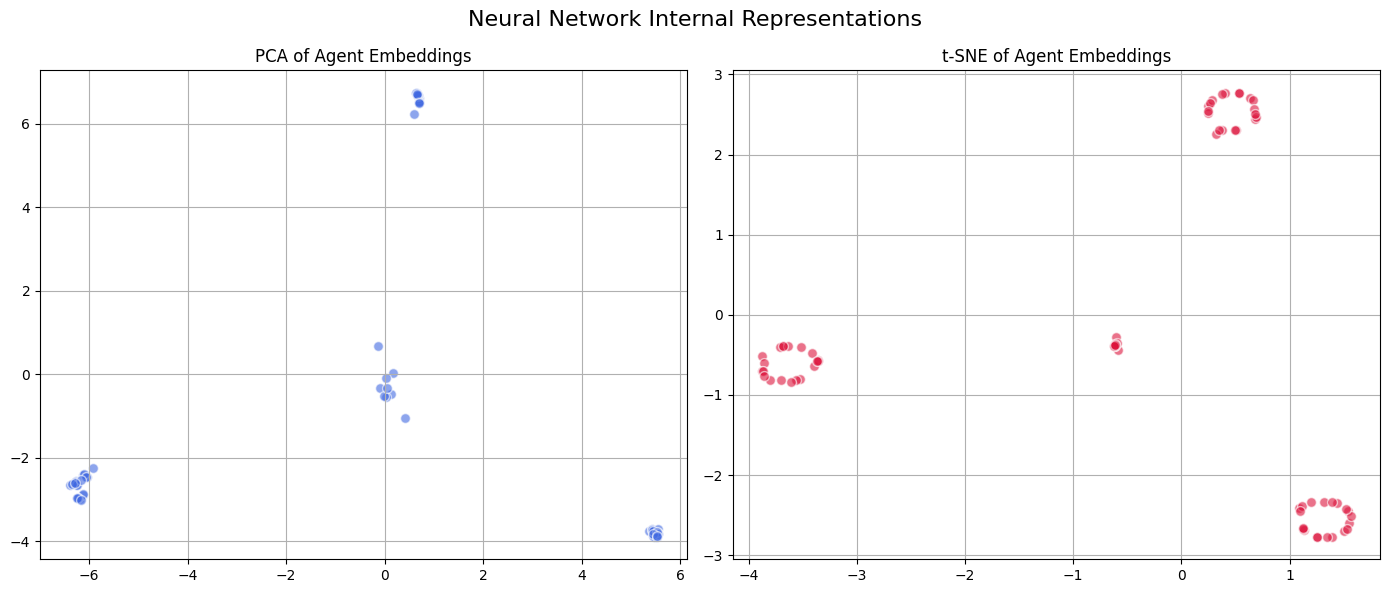

Collected 267 steps. Running PCA and t-SNE (this might take a few seconds)...


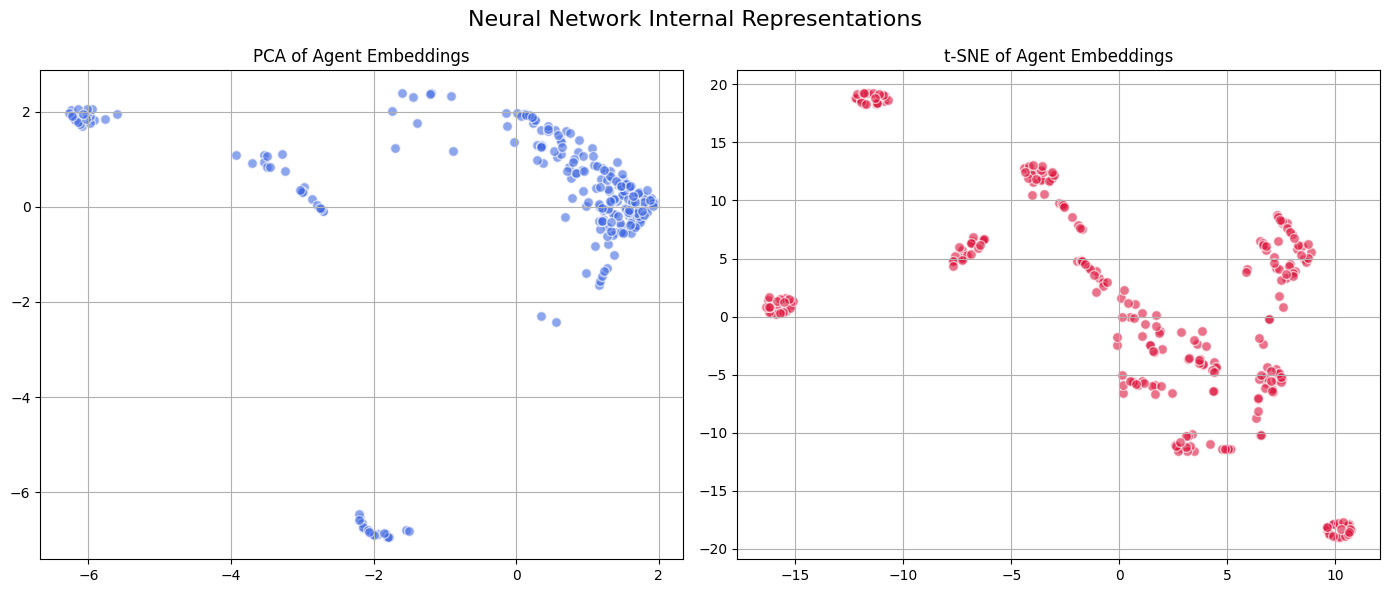

Collected 1603 steps. Running PCA and t-SNE (this might take a few seconds)...


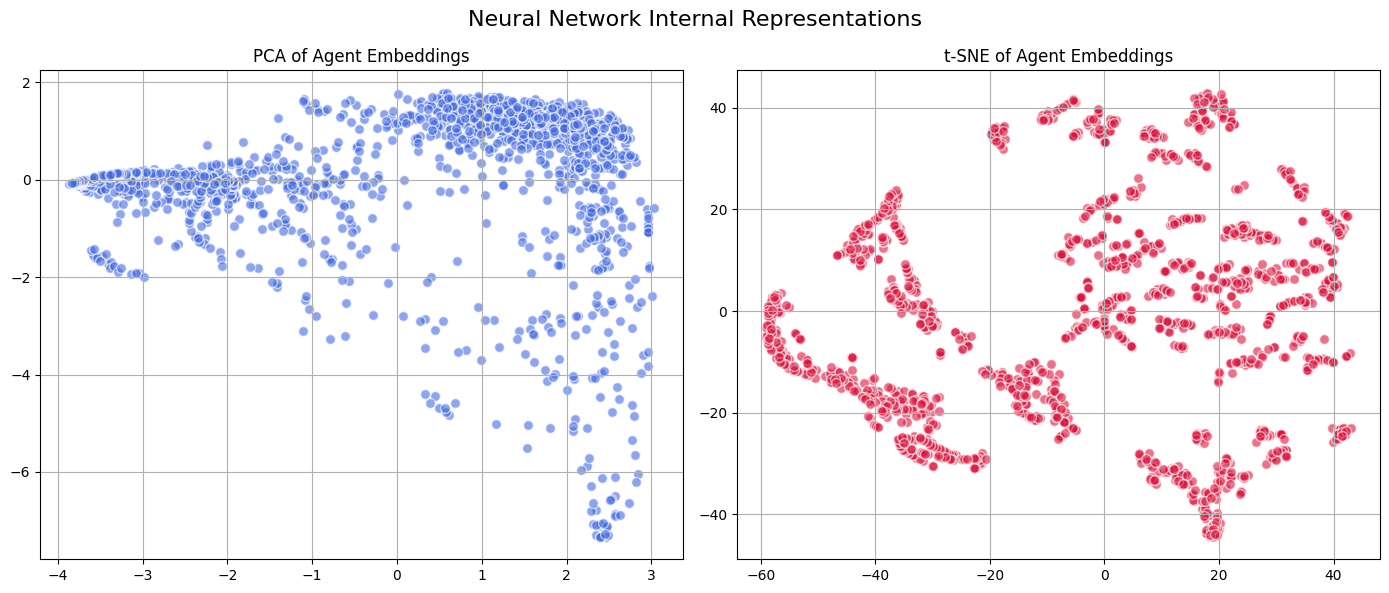

In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

def plot_embeddings(model, env, num_episodes=20):
    print("Collecting observations and brain activations...")
    latent_representations = []
    
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        
        while not done:
            # Convert the dictionary observation to a PyTorch tensor
            obs_tensor, _ = model.policy.obs_to_tensor(obs)
            
            # Pass it through the network to get the internal "latent" features
            with torch.no_grad():
                features = model.policy.extract_features(obs_tensor)
                # mlp_extractor returns (latent_policy, latent_value)
                latent_pi = model.policy.mlp_extractor.forward(features)[0] 
                
            latent_representations.append(latent_pi.cpu().numpy().flatten())
            
            # Take the action in the environment
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

    embeddings = np.array(latent_representations)
    print(f"Collected {len(embeddings)} steps. Running PCA and t-SNE (this might take a few seconds)...")

    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(embeddings)

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    tsne_result = tsne.fit_transform(embeddings)

    # Plotting the results
    fig, ax = plt.subplots(1, 2, figsize=(14, 6))
    
    ax[0].scatter(pca_result[:, 0], pca_result[:, 1], alpha=0.6, c='royalblue', edgecolors='w', s=50)
    ax[0].set_title('PCA of Agent Embeddings')
    ax[0].grid(True)
    
    ax[1].scatter(tsne_result[:, 0], tsne_result[:, 1], alpha=0.6, c='crimson', edgecolors='w', s=50)
    ax[1].set_title('t-SNE of Agent Embeddings')
    ax[1].grid(True)
    
    plt.suptitle('Neural Network Internal Representations', fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualization
plot_embeddings(model_easy, e_env_e, num_episodes=20)
plot_embeddings(model_medium, e_env_m, num_episodes=20)
plot_embeddings(model_hard, e_env_h, num_episodes=20)

***

# 📝 Comprehensive Analysis: Activity Recognition and Reaction

This part evaluates the ability of Reinforcement Learning (RL) agents to recognize sequential events and perform corresponding robotic actions (using a KUKA arm in PyBullet). We tested the agent's capabilities across three difficulty levels, systematically analyzing the limitations of reactive policies and the necessity of temporal memory architectures.

## Part 1: Baseline Performance (Standard PPO)
In our first experiment, we trained a standard Proximal Policy Optimization (PPO) agent using a memory-less Multi-Layer Perceptron (`MultiInputPolicy`). The goal was to establish a baseline and determine which environments could be solved purely reactively.

* **Easy (v0) and Medium (v1) Environments:** * **Results:** The agent achieved a perfect **100% success rate** with highly efficient paths (averaging 3.4 steps for Easy and 13.1 steps for Medium) and a maximized Mean Reward of 3.00.
    * **Insight:** These results mathematically prove that the Easy and Medium tasks are largely **Markovian**. The final event that dictates the correct chest is uniquely identifiable in the immediate observation. The agent did not need to remember the sequence; it simply mapped the final visible state directly to the correct Cartesian movement.
* **Hard (v2) Environment:**
    * **Results:** The baseline agent failed critically. While it stumbled into the correct chest 70% of the time, it required an average of **55.8 steps** and yielded a **negative Mean Reward of -2.62**.
    * **Insight:** The Hard environment is **Non-Markovian**, requiring the agent to remember events that occurred several steps prior. Because the standard PPO agent has no memory, it was effectively "blind". It resorted to a highly inefficient policy, wandering around the environment, accumulating massive time penalties, and randomly guessing the correct chest.

## Part 2: Internal Representations (Embeddings Visualization)
To understand *how* the baseline MLP agent processes the environment, we extracted the latent neural activations across multiple episodes and reduced their dimensionality using **PCA** and **t-SNE**.

* **Continuous Manifolds vs. Discrete Clusters:** Unlike standard classification tasks where t-SNE reveals distinct, isolated clusters (e.g., "Concept A" vs. "Concept B"), our agent's embeddings formed continuous, interconnected blobs. 
* **The Physics Bottleneck:** This occurs because the observation space is dominated by the continuous Cartesian coordinates (X, Y, Z) of the robotic arm. The network's activations change smoothly as the robot moves through physical space.
* **The Amnesia Confirmation:** The lack of clearly separated "memory state" clusters visually confirms why the MLP failed the Hard environment. It never formed distinct internal representations for "Rule A is active" versus "Rule B is active." It only processed the present physical reality.

***

In [12]:
# Save the successful models
model_easy.save("./robotique/ppo_otc_easy")
model_medium.save("./robotique/ppo_otc_medium")

## Frame stacking and LSTM (memory)

/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OpenTheChests-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OpenTheChests-v1 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")
/home/ensta/ensta-chaouch/robotique/venv/lib/python3.12/site-packages/gymnasium/envs/registration.py:636: UserWarning: WARN: Overriding environment OpenTheChests-v2 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")



--- Starting Hard Env | Frame Stacking: 16 ---
Training Frame-Stacked PPO for 500000 timesteps...

--- Starting Hard Env | LSTM ---
Training LSTM for 500000 timesteps...

Generating Training Plots...


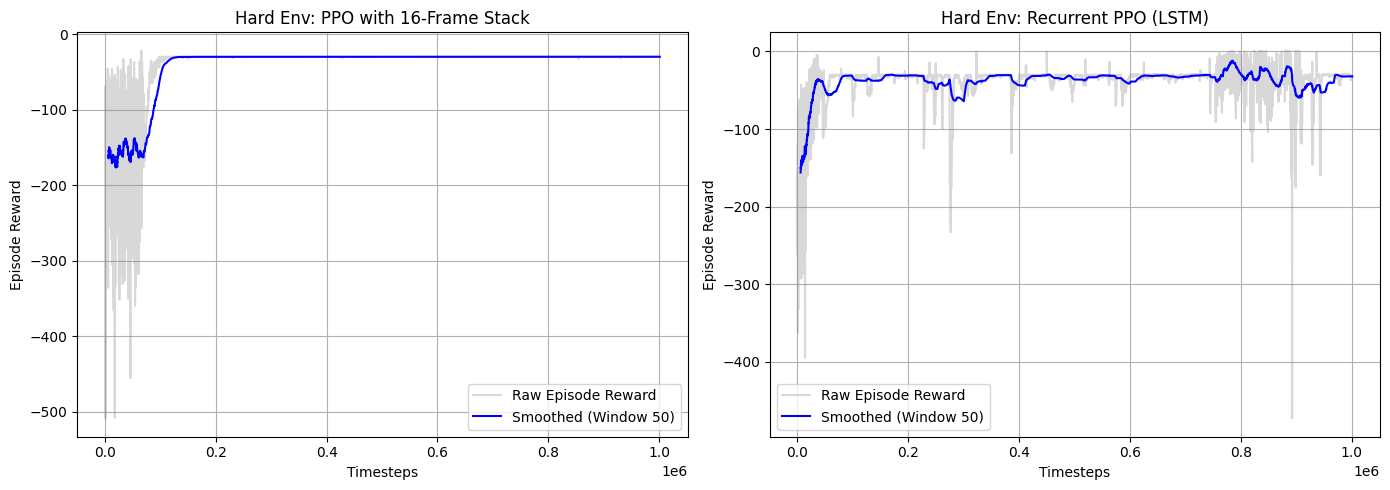

In [3]:
import os
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
import register_envs

# Register the environments
try:
    register_envs.register_custom_envs()
except Exception:
    pass 

# Create directories to save the training logs
log_dir_fs = "./robotique/otc_logs_fs_hard/"
log_dir_lstm = "./robotique/otc_logs_lstm_hard/"
os.makedirs(log_dir_fs, exist_ok=True)
os.makedirs(log_dir_lstm, exist_ok=True)

# ---------------------------------------------------------
# 1. Train Frame-Stacked PPO (Hard)
# ---------------------------------------------------------
print("\n" + "="*50)
print("--- Starting Hard Env | Frame Stacking: 16 ---")
print("="*50)

# Create and wrap training env with Monitor
train_env_fs = gym.make("OpenTheChests-v2", discrete=True)
train_env_fs = Monitor(train_env_fs, log_dir_fs) # Logs raw rewards
train_env_fs = FrameStackObservation(train_env_fs, stack_size=16)

model_fs = PPO("MultiInputPolicy", train_env_fs, n_steps=2048, batch_size=64, ent_coef=0.005, verbose=0)
print("Training Frame-Stacked PPO for 1000000 timesteps...")
model_fs.learn(total_timesteps=1000000)

# ---------------------------------------------------------
# 2. Train LSTM (Hard)
# ---------------------------------------------------------
print("\n" + "="*50)
print("--- Starting Hard Env | LSTM ---")
print("="*50)

# Create and wrap training env with Monitor
train_env_lstm = gym.make("OpenTheChests-v2", discrete=True)
train_env_lstm = Monitor(train_env_lstm, log_dir_lstm) # Logs raw rewards

model_lstm = RecurrentPPO("MultiInputLstmPolicy", train_env_lstm, n_steps=2048, batch_size=64, ent_coef=0.005, verbose=0)
print("Training LSTM for 1000000 timesteps...")
model_lstm.learn(total_timesteps=1000000)


# ---------------------------------------------------------
# 3. Plot the Learning Curves
# ---------------------------------------------------------
def plot_learning_curve(log_folder, ax, title):
    """Helper function to extract log data and plot the smoothed curve."""
    x, y = ts2xy(load_results(log_folder), 'timesteps')
    if len(y) == 0:
        return
    
    # Calculate a moving average to smooth the noisy RL data
    window = min(50, len(y))
    weights = np.repeat(1.0, window) / window
    y_smoothed = np.convolve(y, weights, 'valid')
    x_smoothed = x[len(x) - len(y_smoothed):]

    ax.plot(x, y, alpha=0.3, color='gray', label='Raw Episode Reward')
    ax.plot(x_smoothed, y_smoothed, color='blue', label=f'Smoothed (Window {window})')
    ax.set_xlabel('Timesteps')
    ax.set_ylabel('Episode Reward')
    ax.set_title(title)
    ax.grid(True)
    ax.legend()

print("\nGenerating Training Plots...")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_learning_curve(log_dir_fs, axes[0], "Hard Env: PPO with 16-Frame Stack")
plot_learning_curve(log_dir_lstm, axes[1], "Hard Env: Recurrent PPO (LSTM)")

plt.tight_layout()
plt.show()

In [5]:
# Save the Hard environment models
model_fs.save("./robotique/ppo_otc_hard_fs")
model_lstm.save("./robotique/ppo_otc_hard_lstm")

print("Hard models saved successfully!")

Hard models saved successfully!


## Part 3: Overcoming Temporal Sequences (Advanced Architectures)
For the sequence-dependent Hard environment (`OpenTheChests-v2`), we introduced two techniques to give the agent "memory." Because complex memory tasks suffer from local minima (where the agent stands still to avoid penalties), we aggressively scaled the training to **1,000,000 timesteps**.

### 1. Spatial Memory (PPO with 16-Frame Stacking)
* **Approach:** We wrapped the environment to feed the agent the last 16 observations simultaneously. This transforms a *temporal* sequence problem into a *spatial* pattern recognition problem, allowing standard PPO to solve it.
* **Results:** Looking at the training curves, the Frame-Stacked PPO started deep in a penalty valley (-30 reward), we thinks it's due to the Curse of Dimensionality (the observation array was 16x larger, making early exploration highly noisy).
* **Pros/Cons:** It trains relatively faster computationally, but requires flattening time into a massive input vector, which does not scale well to very long sequences.

### 2. Temporal Memory (Recurrent PPO / LSTM)
* **Approach:** We replaced the MLP with a Long Short-Term Memory (LSTM) network, allowing the agent to dynamically maintain and update a hidden state over time.
* **Results:** The LSTM exhibited severe "Policy Collapse" early on, flatlining at a -30 reward for hundreds of thousands of steps. This visually demonstrates the notorious **sample inefficiency** of LSTMs in RL—learning *what* to remember and *when* to forget via Backpropagation Through Time is incredibly complex. Around a little less than 800000 steps, it managed to peak to achieve the max value across all the training history, but it still remains a challenge to reach a positive reward.
* **Pros/Cons:** While much slower to train and highly sample-inefficient, the LSTM provides a true sequential understanding of the environment without artificially bloating the observation space. It still remains a challenge for LSTM to reach the desired performance, thus maybe opting for a transformer-based architecture might help, an experiment left for future work.

### Final Conclusion for task 2
This analysis demonstrates the fundamental limitations of reactive MLPs in sequential decision-making. While Frame Stacking offers a fast, computationally cheap workaround by leveraging spatial recognition, Recurrent architectures (like LSTMs) provide the most robust, scalable solution for true event-driven robotic control, provided they are given the massive compute budgets and time required to escape early local minima.

## Loading models section

Run this section to evaluate the saved models.

### PPO

In [ ]:
import gymnasium as gym
import numpy as np
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
import register_envs

# Register the environments
try:
    register_envs.register_custom_envs()
except Exception:
    pass

# Helper function for readable insights
def evaluate_success_rate_and_length(model, env, num_episodes=50):
    successes = 0
    episode_lengths = []
    
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        length = 0
        
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            length += 1
            
            if done and reward > 0: 
                successes += 1
                
        episode_lengths.append(length)
        
    success_rate = (successes / num_episodes) * 100
    avg_length = sum(episode_lengths) / len(episode_lengths)
    return success_rate, avg_length

print("\n" + "="*40)
print("--- Evaluating Baseline PPO Models ---")
print("="*40)

# Load and Evaluate Easy Model
env_id_e = "OpenTheChests-v0"
eval_env_e = gym.make(env_id_e)
# Change the filename if you saved it differently
model_easy = PPO.load("./robotique/ppo_otc_easy", env=eval_env_e) 
mean_reward_e, std_reward_e = evaluate_policy(model_easy, eval_env_e, n_eval_episodes=50, deterministic=True)
success_rate_e, avg_length_e = evaluate_success_rate_and_length(model_easy, eval_env_e)
print(f"\n{env_id_e} (Easy) Results:")
print(f"-> Mean Reward: {mean_reward_e:.2f} +/- {std_reward_e:.2f}")
print(f"-> Success Rate: {success_rate_e:.1f}%")
print(f"-> Average Steps: {avg_length_e:.1f}")

# Load and Evaluate Medium Model
env_id_m = "OpenTheChests-v1"
eval_env_m = gym.make(env_id_m)
model_medium = PPO.load("./robotique/ppo_otc_medium", env=eval_env_m)
mean_reward_m, std_reward_m = evaluate_policy(model_medium, eval_env_m, n_eval_episodes=50, deterministic=True)
success_rate_m, avg_length_m = evaluate_success_rate_and_length(model_medium, eval_env_m)
print(f"\n{env_id_m} (Medium) Results:")
print(f"-> Mean Reward: {mean_reward_m:.2f} +/- {std_reward_m:.2f}")
print(f"-> Success Rate: {success_rate_m:.1f}%")
print(f"-> Average Steps: {avg_length_m:.1f}")

### Frame stacking and LSTM

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import FrameStackObservation
import numpy as np
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.evaluation import evaluate_policy
import register_envs

# Register the environments
try:
    register_envs.register_custom_envs()
except Exception:
    pass 

# Helper function specifically for LSTM (manages hidden states)
def evaluate_success_rate_and_length_lstm(model, env, num_episodes=50):
    successes = 0
    episode_lengths = []
    
    for _ in range(num_episodes):
        obs, _ = env.reset()
        done = False
        length = 0
        
        lstm_states = None
        episode_starts = np.ones((1,), dtype=bool) 
        
        while not done:
            action, lstm_states = model.predict(
                obs, 
                state=lstm_states, 
                episode_start=episode_starts, 
                deterministic=True
            )
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            length += 1
            episode_starts = np.zeros((1,), dtype=bool)
            
            if done and reward > 0: 
                successes += 1
                
        episode_lengths.append(length)
        
    success_rate = (successes / num_episodes) * 100
    avg_length = sum(episode_lengths) / len(episode_lengths)
    return success_rate, avg_length

print("\n" + "="*45)
print("--- Evaluating Advanced Models (Hard Env) ---")
print("="*45)

env_id = "OpenTheChests-v2"

# ---------------------------------------------------------
# Load Frame-Stacked PPO (Hard)
# ---------------------------------------------------------
# We must recreate the exact same wrapper structure the model was trained on
eval_env_fs = gym.make(env_id, discrete=True)
eval_env_fs = FrameStackObservation(eval_env_fs, stack_size=16)

model_fs = PPO.load("./robotique/ppo_otc_hard_fs", env=eval_env_fs)

mean_reward_fs, std_reward_fs = evaluate_policy(model_fs, eval_env_fs, n_eval_episodes=50, deterministic=True)
success_rate_fs, avg_length_fs = evaluate_success_rate_and_length(model_fs, eval_env_fs)

print("\nFrame-Stacked PPO (16 Frames) Results:")
print(f"-> Mean Reward: {mean_reward_fs:.2f} +/- {std_reward_fs:.2f}")
print(f"-> Success Rate: {success_rate_fs:.1f}%")
print(f"-> Average Steps: {avg_length_fs:.1f}")

# ---------------------------------------------------------
# Load Recurrent PPO (LSTM) (Hard)
# ---------------------------------------------------------
eval_env_lstm = gym.make(env_id, discrete=True)
model_lstm = RecurrentPPO.load("./robotique/ppo_otc_hard_lstm", env=eval_env_lstm)

mean_reward_lstm, std_reward_lstm = evaluate_policy(model_lstm, eval_env_lstm, n_eval_episodes=50, deterministic=True)
success_rate_lstm, avg_length_lstm = evaluate_success_rate_and_length_lstm(model_lstm, eval_env_lstm)

print("\nRecurrent PPO (LSTM) Results:")
print(f"-> Mean Reward: {mean_reward_lstm:.2f} +/- {std_reward_lstm:.2f}")
print(f"-> Success Rate: {success_rate_lstm:.1f}%")
print(f"-> Average Steps: {avg_length_lstm:.1f}")